#  EDA and Visualization — Product Recommendation System

## 1. Import Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')          
pd.set_option('display.max_columns', None) # Show all columns in output

## 2. Load Dataset

In [2]:
# Load the ratings CSV file
# header=None → because the file has no column header row
df = pd.read_csv("ratings.csv", header=None)
df.head()

,0,1,2,3
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [3]:
# Assign proper column names to the dataset
df.columns = ['userId', 'productId', 'Rating', 'timestamp']
df.head()

,userId,productId,Rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [4]:
# Drop 'timestamp' — not needed for recommendation system
df = df.drop('timestamp', axis=1)
df.head()

,userId,productId,Rating
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


## 3. Basic Dataset Information

In [63]:
# Check total number of rows and columns
df.shape

(7824482, 3)

In [6]:
# Get dataset info: column types, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     object 
 1   productId  object 
 2   Rating     float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


In [7]:
# Statistical summary: mean, std, min, max, quartiles
df.describe()

,Rating
count,7.824482e+06
mean,4.012337e+00
std,1.380910e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


In [8]:
# Check data types of each column
df.dtypes

userId        object
productId     object
Rating       float64
dtype: object

## 4. Null Values & Duplicate Check

In [9]:
# Check for missing/null values in each column
df.isnull().sum()

userId       0
productId    0
Rating       0
dtype: int64

In [64]:
# Check for duplicate 
df.duplicated().sum()

np.int64(0)

## 5. Unique Users & Products

In [11]:
# Count how many unique users are in the dataset
print("Unique Users   :", df['userId'].nunique())

# Count how many unique products are in the dataset
print("Unique Products:", df['productId'].nunique())

# Total ratings recorded
print("Total Ratings  :", df.shape[0])

Unique Users   : 4201696
Unique Products: 476002
Total Ratings  : 7824482


## 6. Rating Distribution

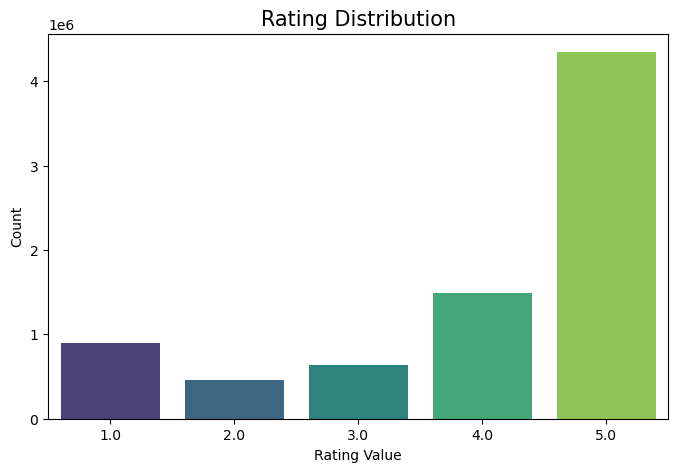

In [12]:
# BAR CHART — How many times each rating value appears
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Rating',
    data=df,
    palette='viridis'
)
plt.title("Rating Distribution", fontsize=15)
plt.xlabel("Rating Value")
plt.ylabel("Count")
plt.show()

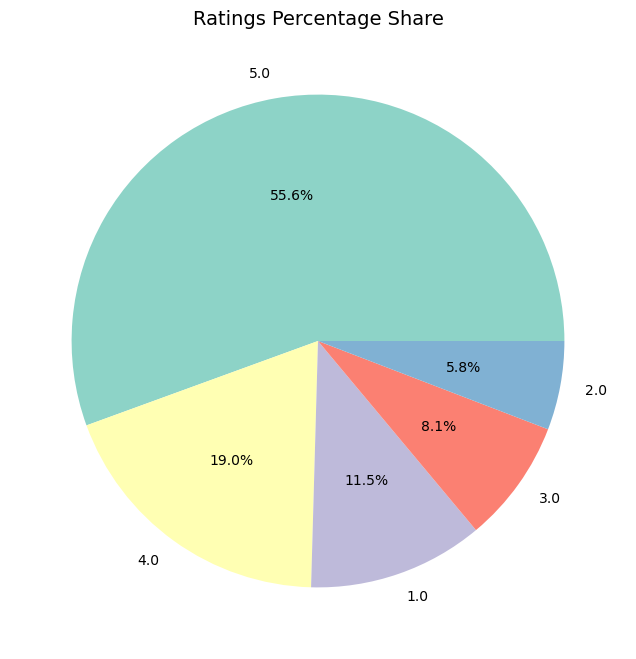

In [13]:
# PIE CHART — Percentage share of each rating value
rating_counts = df['Rating'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3')
)
plt.title("Ratings Percentage Share", fontsize=14)
plt.show()

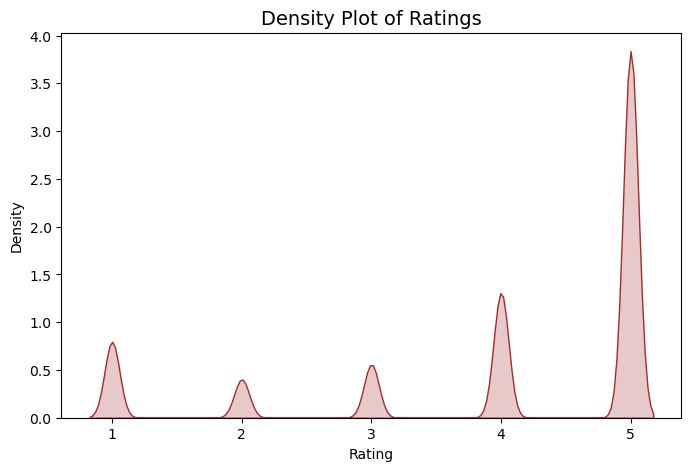

In [14]:
# KDE PLOT — Smooth density curve of rating values
# Helps understand the overall rating pattern
plt.figure(figsize=(8, 5))
sns.kdeplot(
    df['Rating'],
    fill=True,
    color='brown'
)
plt.title("Density Plot of Ratings", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Density")
plt.show()

## 7. Top Products & Active Users

In [15]:
# Get the 10 most rated products (most popular by rating count)
top_products = df['productId'].value_counts().head(10)
print(top_products)

productId
B0074BW614    18244
B00DR0PDNE    16454
B007WTAJTO    14172
B0019EHU8G    12285
B006GWO5WK    12226
B003ELYQGG    11617
B003ES5ZUU    10276
B007R5YDYA     9907
B00622AG6S     9823
B0002L5R78     9487
Name: count, dtype: int64


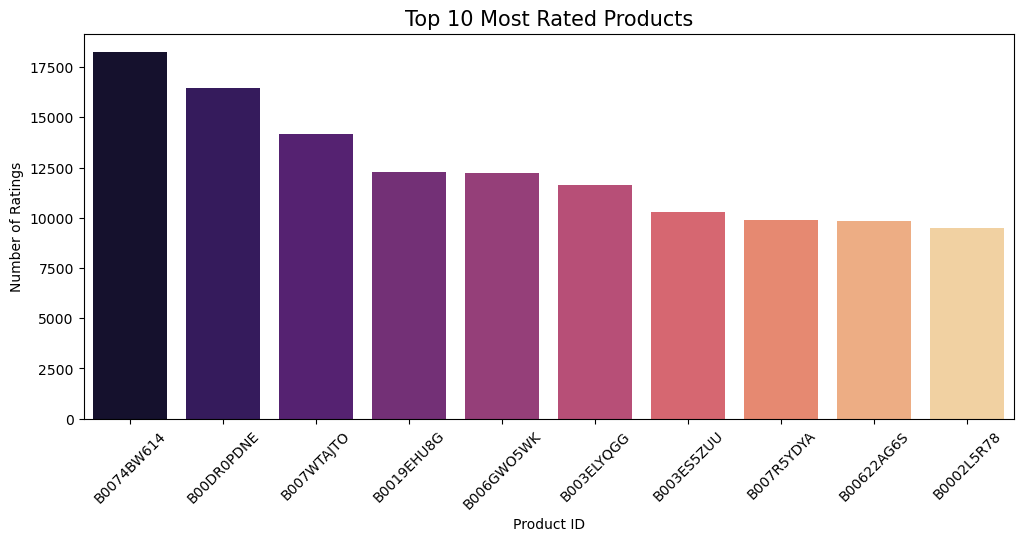

In [16]:
# BAR CHART — Visualize top 10 most rated products
plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_products.index,
    y=top_products.values,
    palette='magma'
)
plt.title("Top 10 Most Rated Products", fontsize=15)
plt.xlabel("Product ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()

In [17]:
# Get top 10 most active users (users who gave the most ratings)
top_users = df['userId'].value_counts().head(10)
print(top_users)

userId
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
ARBKYIVNYWK3C     296
Name: count, dtype: int64


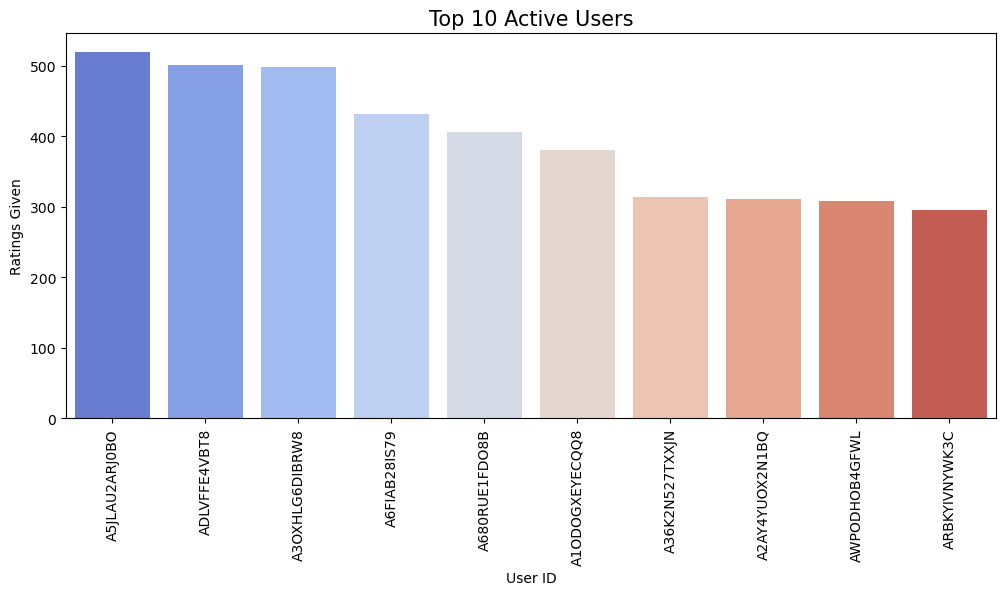

In [18]:
# BAR CHART — Visualize top 10 most active users
plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_users.index,
    y=top_users.values,
    palette='coolwarm'
)
plt.title("Top 10 Active Users", fontsize=15)
plt.xlabel("User ID")
plt.ylabel("Ratings Given")
plt.xticks(rotation=90)
plt.show()

## 8. Average Product Rating (With Minimum Rating Filter)

In [19]:
# Calculate average rating for each product
avg_rating = df.groupby('productId')['Rating'].mean()

# Count how many ratings each product received
ratings_per_product = df.groupby('productId')['Rating'].count()

# Apply minimum rating filter - avoid products with only 1-2 ratings
# A product with 1 rating of 5.0 should NOT be in top rated list
min_ratings = 10

# Filter: only products with at least 10 ratings
avg_rating_filtered = avg_rating[ratings_per_product >= min_ratings]

# Sort by highest average rating and take top 10
top_avg_rating = avg_rating_filtered.sort_values(ascending=False).head(10)
print(top_avg_rating)

productId
B0000A1H8Z    5.0
B00180F2Z4    5.0
B002R6KZLO    5.0
B00A01G350    5.0
B000WNU5YG    5.0
B001H9O14O    5.0
B0036MN38K    5.0
B000X4421Q    5.0
B00HVTSTI8    5.0
B005OQ0XIO    5.0
Name: Rating, dtype: float64


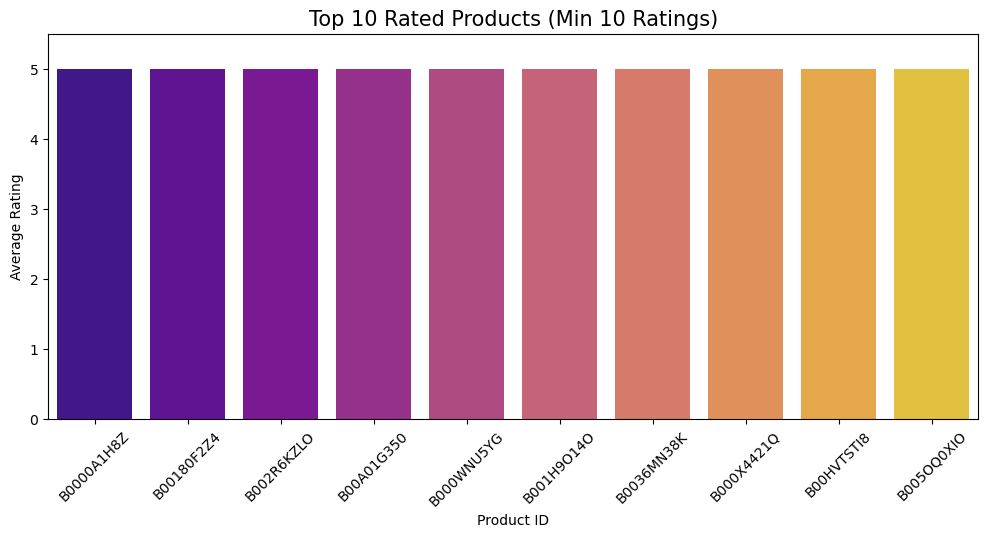

In [20]:
# BAR CHART — Top 10 highest rated products (reliable, min 10 ratings)
plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_avg_rating.index,
    y=top_avg_rating.values,
    palette='plasma'
)
plt.title("Top 10 Rated Products (Min 10 Ratings)", fontsize=15)
plt.xlabel("Product ID")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(0, 5.5)
plt.show()

## 9. Ratings Per User & Per Product Distribution

In [21]:
# Count how many ratings each user has given
ratings_per_user = df.groupby('userId')['Rating'].count()
ratings_per_user.head()

userId
A00000262KYZUE4J55XGL    1
A000063614T1OE0BUSKUT    2
A00009182QVLSWIGHLS1B    1
A00009661LC9LQPGKJ24G    1
A00010809P09NUU6ZP6H     1
Name: Rating, dtype: int64

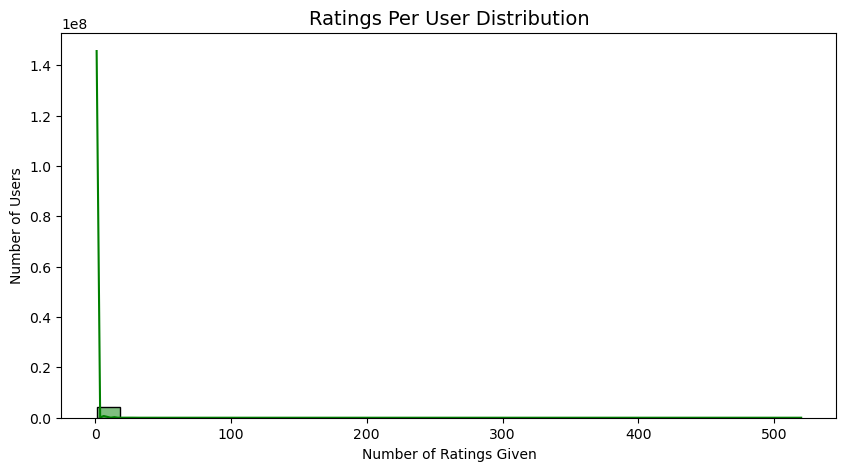

In [67]:
# HISTOGRAM — Distribution of ratings given per user
# Most users rate very few products (long tail behavior)
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_user, bins=30, color='green', kde=True)
plt.title("Ratings Per User Distribution", fontsize=14)
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")
plt.show()

In [23]:
# Count how many ratings each product has received
ratings_per_product = df.groupby('productId')['Rating'].count()
ratings_per_product.head()

productId
0132793040     1
0321732944     1
0439886341     3
0511189877     6
0528881469    27
Name: Rating, dtype: int64

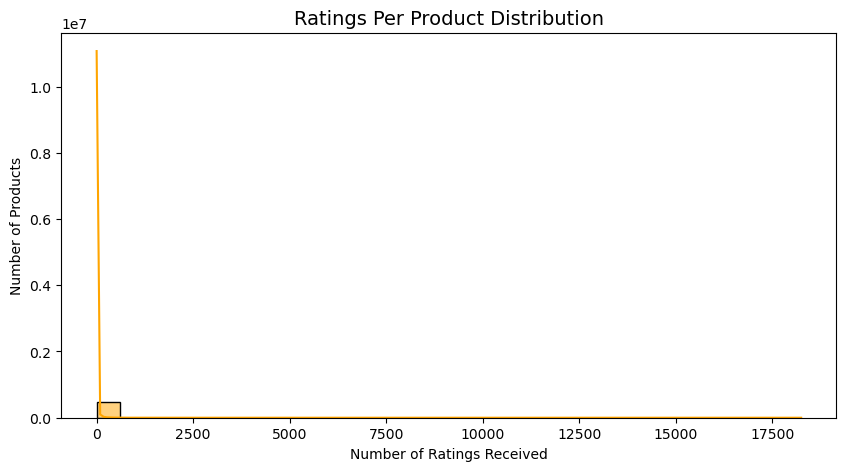

In [24]:
# HISTOGRAM — Distribution of ratings received per product
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_product, bins=30, color='orange', kde=True)
plt.title("Ratings Per Product Distribution", fontsize=14)
plt.xlabel("Number of Ratings Received")
plt.ylabel("Number of Products")
plt.show()

## 10. Outlier Detection & Treatment

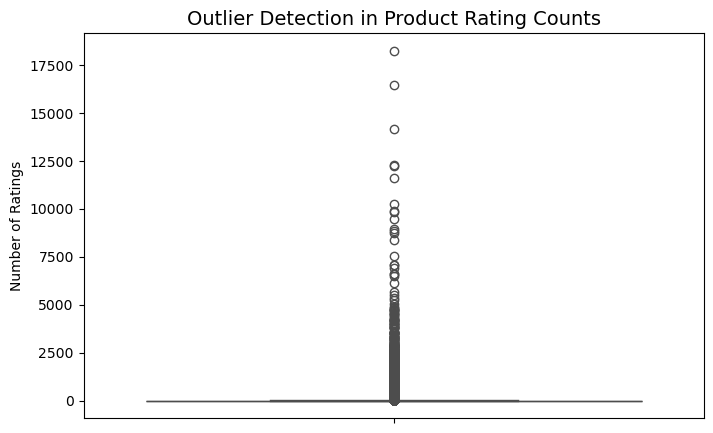

In [25]:
# BOXPLOT — Detect outliers in product rating counts
# Points beyond the whiskers are outliers
plt.figure(figsize=(8, 5))
sns.boxplot(y=ratings_per_product, color='red')
plt.title("Outlier Detection in Product Rating Counts", fontsize=14)
plt.ylabel("Number of Ratings")
plt.show()

In [26]:
# DETECT OUTLIERS USING IQR METHOD
# IQR = Interquartile Range = Q3 - Q1
# Lower Limit = Q1 - 1.5 * IQR
# Upper Limit = Q3 + 1.5 * IQR

Q1 = ratings_per_product.quantile(0.25)  # 25th percentile
Q3 = ratings_per_product.quantile(0.75)  # 75th percentile
IQR = Q3 - Q1                            # Interquartile range

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR                 :", IQR)
print("Lower Limit         :", lower_limit)
print("Upper Limit         :", upper_limit)

Q1 (25th percentile): 1.0
Q3 (75th percentile): 7.0
IQR                 : 6.0
Lower Limit         : -8.0
Upper Limit         : 16.0


In [27]:
# DISPLAY OUTLIER PRODUCTS
# These products have unusually high or low rating counts
outliers = ratings_per_product[
    (ratings_per_product < lower_limit) |
    (ratings_per_product > upper_limit)
]
print("Number of Outlier Products:", len(outliers))
outliers.head(10)

Number of Outlier Products: 65660


productId
0528881469      27
0594481813      31
0972683275    1051
0979526191      20
1394860919      23
1400501466     250
1400501474      29
1400501520      82
1400501741      26
1400501776     139
Name: Rating, dtype: int64

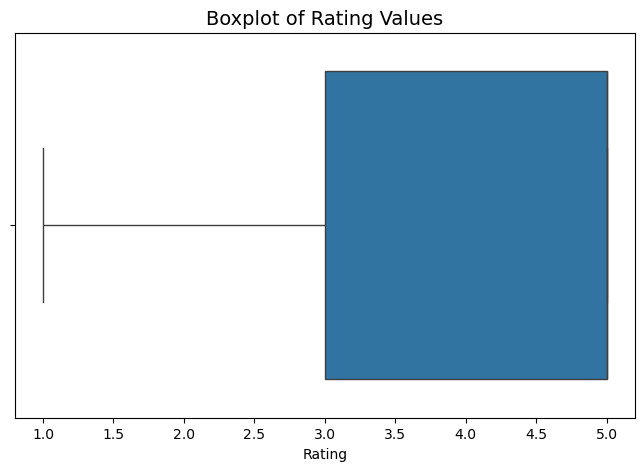

In [28]:
# BOXPLOT — Raw rating values (not counts)
# Check if rating values themselves have outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Rating'])
plt.title("Boxplot of Rating Values", fontsize=14)
plt.show()

In [29]:
# OUTLIER CAPPING — Replace extreme values with boundary limits
# Values above upper_limit → capped to upper_limit
# Values below lower_limit → capped to lower_limit
ratings_per_product_capped = np.where(
    ratings_per_product > upper_limit, upper_limit, ratings_per_product
)
ratings_per_product_capped = np.where(
    ratings_per_product_capped < lower_limit, lower_limit, ratings_per_product_capped
)
print("Outlier capping done.")

Outlier capping done.


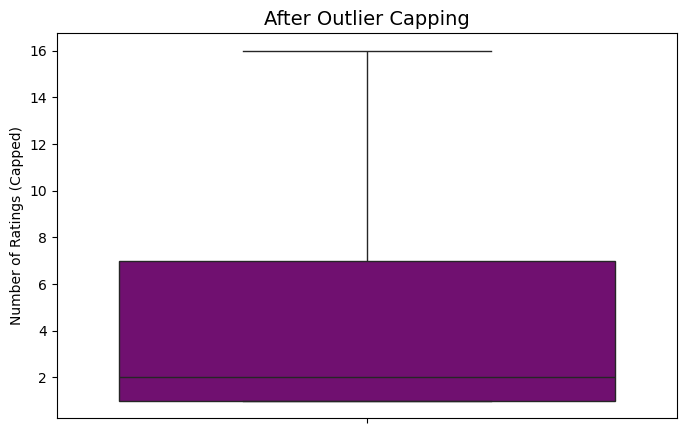

In [30]:
# BOXPLOT AFTER CAPPING — Compare with before
plt.figure(figsize=(8, 5))
sns.boxplot(y=ratings_per_product_capped, color='purple')
plt.title("After Outlier Capping", fontsize=14)
plt.ylabel("Number of Ratings (Capped)")
plt.show()

## 11. Average Rating vs Rating Count (Scatter Plot)

In [31]:
# Aggregate: average rating AND count per product in one table
product_stats = df.groupby('productId').agg({'Rating': ['mean', 'count']})
product_stats.columns = ['Average_Rating', 'Rating_Count']
product_stats.head()

,Average_Rating,Rating_Count
productId,,
0132793040,5.000000,1
0321732944,5.000000,1
0439886341,1.666667,3
0511189877,4.500000,6
0528881469,2.851852,27


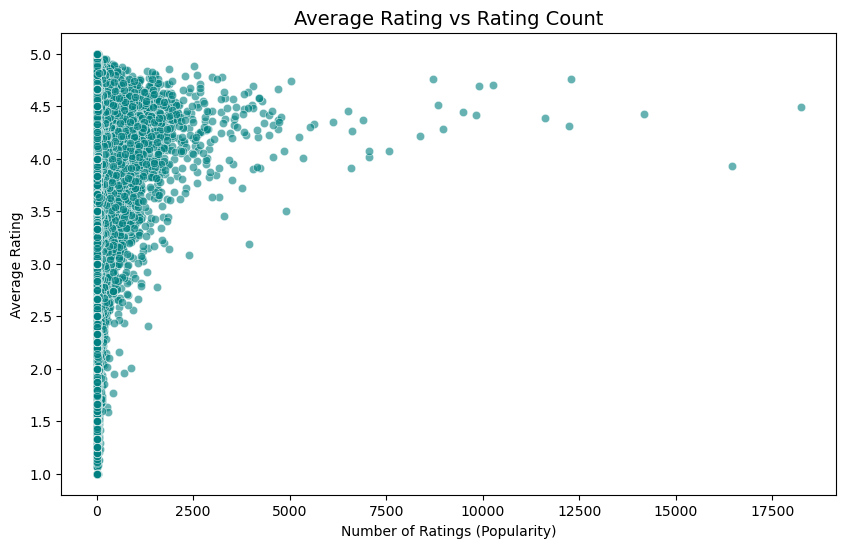

In [32]:
# SCATTER PLOT — Does a product with more ratings have higher avg rating?
# Helps identify reliable vs unreliable products
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=product_stats['Rating_Count'],
    y=product_stats['Average_Rating'],
    color='teal',
    alpha=0.6
)
plt.title("Average Rating vs Rating Count", fontsize=14)
plt.xlabel("Number of Ratings (Popularity)")
plt.ylabel("Average Rating")
plt.show()

## 12. Long Tail Distribution

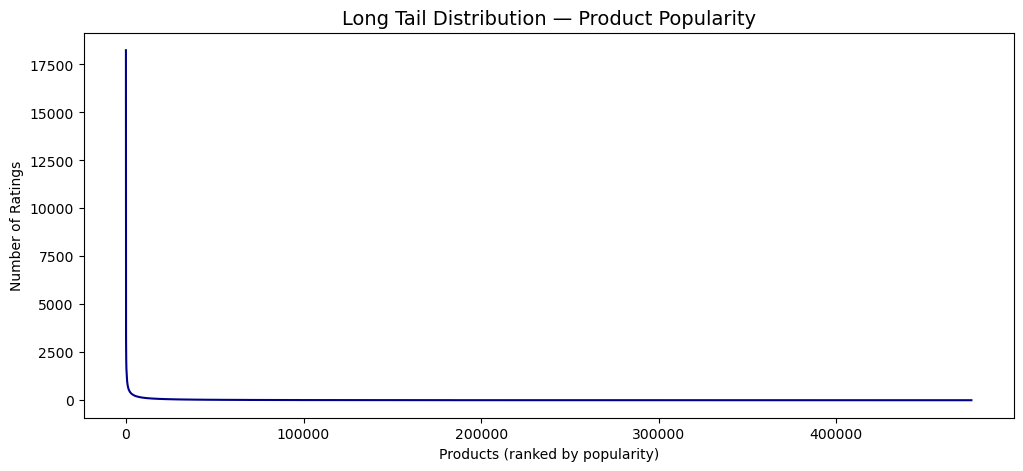

In [33]:
# LONG TAIL DISTRIBUTION
# A few products get most ratings, majority get very few
# This is typical of recommendation system datasets
product_rating_counts = df['productId'].value_counts()

plt.figure(figsize=(12, 5))
plt.plot(product_rating_counts.values, color='darkblue')
plt.title("Long Tail Distribution — Product Popularity", fontsize=14)
plt.xlabel("Products (ranked by popularity)")
plt.ylabel("Number of Ratings")
plt.show()

## 13. User Rating Behavior Analysis (Harsh vs Generous Raters)

In [34]:
# Analyze how each user rates on average
# Are they generous (give 4-5) or harsh (give 1-2)?
user_behavior = df.groupby('userId')['Rating'].agg(
    Avg_Rating='mean',
    Total_Ratings='count',
    Rating_Std='std'       # Standard deviation = consistency of ratings
).reset_index()

# Users who rated only 1 product have no std → fill with 0
user_behavior['Rating_Std'] = user_behavior['Rating_Std'].fillna(0)

print("User Behavior Summary:")
print(user_behavior.describe())
user_behavior.head(10)

User Behavior Summary:
         Avg_Rating  Total_Ratings    Rating_Std
count  4.201696e+06   4.201696e+06  4.201696e+06
mean   3.910163e+00   1.862220e+00  2.673192e-01
std    1.361308e+00   2.885110e+00  6.090702e-01
min    1.000000e+00   1.000000e+00  0.000000e+00
25%    3.000000e+00   1.000000e+00  0.000000e+00
50%    4.500000e+00   1.000000e+00  0.000000e+00
75%    5.000000e+00   2.000000e+00  0.000000e+00
max    5.000000e+00   5.200000e+02  2.828427e+00


,userId,Avg_Rating,Total_Ratings,Rating_Std
0,A00000262KYZUE4J55XGL,5.0,1,0.0
1,A000063614T1OE0BUSKUT,5.0,2,0.0
2,A00009182QVLSWIGHLS1B,5.0,1,0.0
3,A00009661LC9LQPGKJ24G,5.0,1,0.0
4,A00010809P09NUU6ZP6H,5.0,1,0.0
5,A00014061C2IZNE0YEILY,4.0,1,0.0
6,A000145014WOTZJ5NSKOR,5.0,1,0.0
7,A00015222LZ55IJSVL5IX,1.0,1,0.0
8,A00015228CUPGPF957DS,1.0,1,0.0
9,A0001528BGUBOEVR6T5U,4.5,4,1.0


In [35]:
# CLASSIFY users into rater types based on average rating
def classify_rater(avg):
    if avg >= 4.0:
        return 'Generous (4-5)'   # Tends to give high ratings
    elif avg >= 3.0:
        return 'Neutral (3-4)'    # Gives moderate ratings
    else:
        return 'Harsh (1-3)'      # Tends to give low ratings

user_behavior['Rater_Type'] = user_behavior['Avg_Rating'].apply(classify_rater)

# Show count of each rater type
print(user_behavior['Rater_Type'].value_counts())

Rater_Type
Generous (4-5)    2900672
Harsh (1-3)        783068
Neutral (3-4)      517956
Name: count, dtype: int64


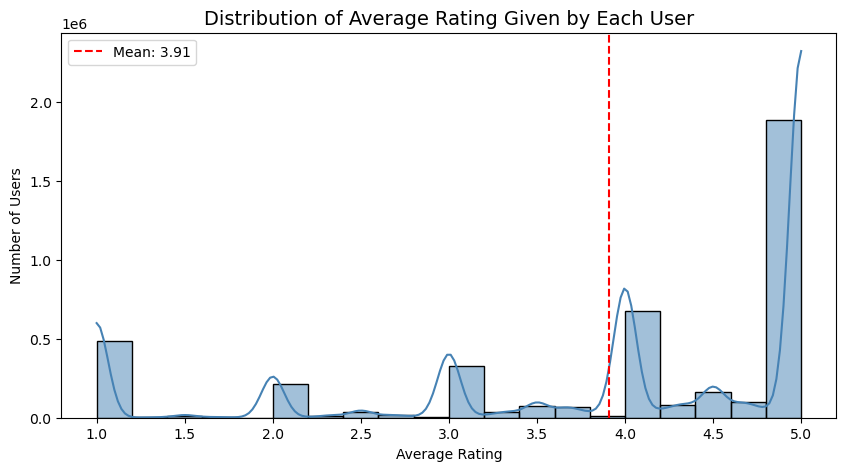

In [36]:
# HISTOGRAM — Distribution of average rating given per user
plt.figure(figsize=(10, 5))
sns.histplot(user_behavior['Avg_Rating'], bins=20, kde=True, color='steelblue')
plt.axvline(
    user_behavior['Avg_Rating'].mean(),
    color='red', linestyle='--',
    label=f"Mean: {user_behavior['Avg_Rating'].mean():.2f}"
)
plt.title("Distribution of Average Rating Given by Each User", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.legend()
plt.show()

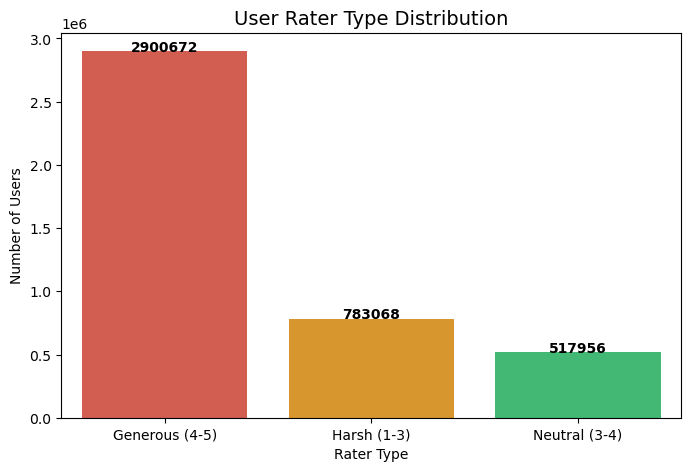

In [37]:
# BAR CHART — Count of Harsh vs Neutral vs Generous raters
rater_counts = user_behavior['Rater_Type'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=rater_counts.index,
    y=rater_counts.values,
    palette=['#e74c3c', '#f39c12', '#2ecc71']
)
plt.title("User Rater Type Distribution", fontsize=14)
plt.xlabel("Rater Type")
plt.ylabel("Number of Users")
for i, v in enumerate(rater_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

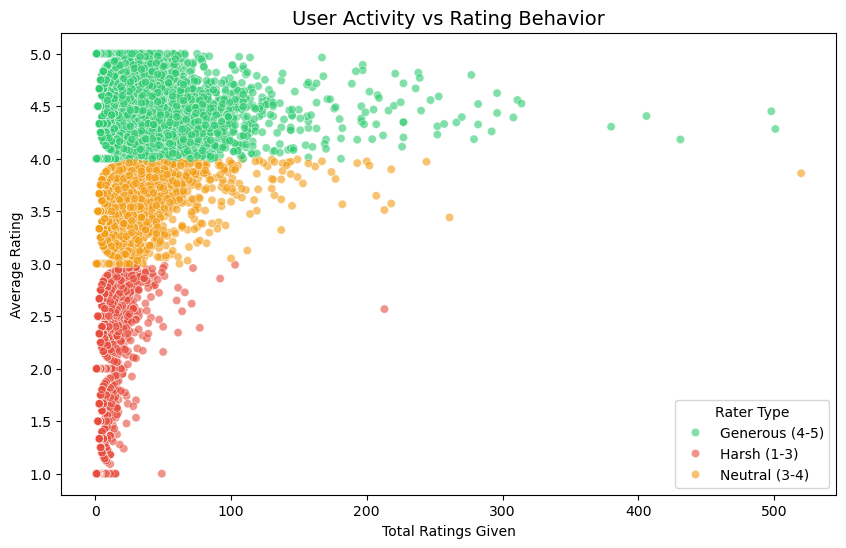

In [38]:
# SCATTER PLOT — Activity vs Rating Behavior
# Do more active users tend to rate higher or lower?
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=user_behavior,
    x='Total_Ratings',
    y='Avg_Rating',
    hue='Rater_Type',
    palette={
        'Generous (4-5)': '#2ecc71',
        'Neutral (3-4)' : '#f39c12',
        'Harsh (1-3)'   : '#e74c3c'
    },
    alpha=0.6
)
plt.title("User Activity vs Rating Behavior", fontsize=14)
plt.xlabel("Total Ratings Given")
plt.ylabel("Average Rating")
plt.legend(title="Rater Type")
plt.show()

## 14. Pivot Table — User × Product Rating Matrix

In [39]:
# FILTER DATA — Keep only active users and popular products
# This makes the pivot table meaningful and not too sparse

min_user_ratings    = 5   # User must have rated at least 5 products
min_product_ratings = 10  # Product must have received at least 10 ratings

active_users     = df['userId'].value_counts()
active_users     = active_users[active_users >= min_user_ratings].index

popular_products = df['productId'].value_counts()
popular_products = popular_products[popular_products >= min_product_ratings].index

# Filter the dataframe
df_filtered = df[
    df['userId'].isin(active_users) &
    df['productId'].isin(popular_products)
]

print(f"Original  Shape  : {df.shape}")
print(f"Filtered  Shape  : {df_filtered.shape}")
print(f"Active Users     : {df_filtered['userId'].nunique()}")
print(f"Popular Products : {df_filtered['productId'].nunique()}")

Original  Shape  : (7824482, 3)
Filtered  Shape  : (1991560, 3)
Active Users     : 253895
Popular Products : 95177


In [57]:
# ============================================================
# MEMORY-SAFE PIVOT TABLE — User × Product Rating Matrix
# Full pivot_table() crashes → 22.5 GB RAM needed
# Fix: Sample only top 500 users × top 500 products
# ============================================================

TOP_USERS    = 500
TOP_PRODUCTS = 500

# Select top active users and popular products
top_user_ids    = df['userId'].value_counts().head(TOP_USERS).index
top_product_ids = df['productId'].value_counts().head(TOP_PRODUCTS).index

# Filter to only those users and products
df_sample = df[
    df['userId'].isin(top_user_ids) &
    df['productId'].isin(top_product_ids)
]

# Create pivot table — now memory safe
pivot_table = df_sample.pivot_table(
    index='userId',
    columns='productId',
    values='Rating',
    aggfunc='mean'
)

# Statistics
filled   = pivot_table.notna().sum().sum()
total    = pivot_table.shape[0] * pivot_table.shape[1]
sparsity = 1 - (filled / total)

print(f"Pivot Table Shape : {pivot_table.shape}")
print(f"Filled Cells      : {filled:,}")
print(f"Missing (NaN)     : {total - filled:,}")
print(f"Sparsity          : {sparsity * 100:.2f}%")



Pivot Table Shape : (495, 476)
Filled Cells      : 5,071
Missing (NaN)     : 230,549
Sparsity          : 97.85%


In [58]:
# PIVOT TABLE STATISTICS
filled   = pivot_table.notna().sum().sum()          # Cells with actual ratings
total    = pivot_table.shape[0] * pivot_table.shape[1]  # All cells
missing  = total - filled
sparsity = 1 - (filled / total)

print("=" * 42)
print(f"  Total Users      : {pivot_table.shape[0]}")
print(f"  Total Products   : {pivot_table.shape[1]}")
print(f"  Total Cells      : {total}")
print(f"  Filled Cells     : {filled}")
print(f"  Missing (NaN)    : {missing}")
print(f"  Sparsity         : {sparsity * 100:.2f}%")
print("=" * 42)

  Total Users      : 495
  Total Products   : 476
  Total Cells      : 235620
  Filled Cells     : 5071
  Missing (NaN)    : 230549
  Sparsity         : 97.85%


In [59]:
# PRODUCT SUMMARY PIVOT TABLE — Avg Rating, Count, Std Dev per Product
product_summary = df.pivot_table(
    index='productId',
    values='Rating',
    aggfunc=['mean', 'count', 'std']
)
product_summary.columns = ['Avg_Rating', 'Rating_Count', 'Rating_Std']
product_summary = product_summary.sort_values('Rating_Count', ascending=False)

print("Top 10 Products by Popularity:")
product_summary.head(10)

Top 10 Products by Popularity:


,Avg_Rating,Rating_Count,Rating_Std
productId,,,
B0074BW614,4.491504,18244,0.953553
B00DR0PDNE,3.931020,16454,1.351375
B007WTAJTO,4.424005,14172,1.208874
B0019EHU8G,4.754497,12285,0.757765
B006GWO5WK,4.314657,12226,1.179183
B003ELYQGG,4.392528,11617,1.059364
B003ES5ZUU,4.704749,10276,0.785898
B007R5YDYA,4.690926,9907,0.716933
B00622AG6S,4.420136,9823,1.143408


In [60]:
# USER SUMMARY PIVOT TABLE — Avg Rating, Count, Std Dev per User
user_summary = df.pivot_table(
    index='userId',
    values='Rating',
    aggfunc=['mean', 'count', 'std']
)
user_summary.columns = ['Avg_Rating_Given', 'Total_Ratings', 'Rating_Std']
user_summary = user_summary.sort_values('Total_Ratings', ascending=False)

print("Top 10 Most Active Users:")
user_summary.head(10)

Top 10 Most Active Users:


,Avg_Rating_Given,Total_Ratings,Rating_Std
userId,,,
A5JLAU2ARJ0BO,3.861538,520,1.466407
ADLVFFE4VBT8,4.283433,501,0.960992
A3OXHLG6DIBRW8,4.451807,498,0.693957
A6FIAB28IS79,4.183295,431,0.998277
A680RUE1FDO8B,4.406404,406,1.128687
A1ODOGXEYECQQ8,4.305263,380,0.705406
A36K2N527TXXJN,4.525478,314,0.630169
A2AY4YUOX2N1BQ,4.559486,311,0.663931
AWPODHOB4GFWL,4.392857,308,0.915776


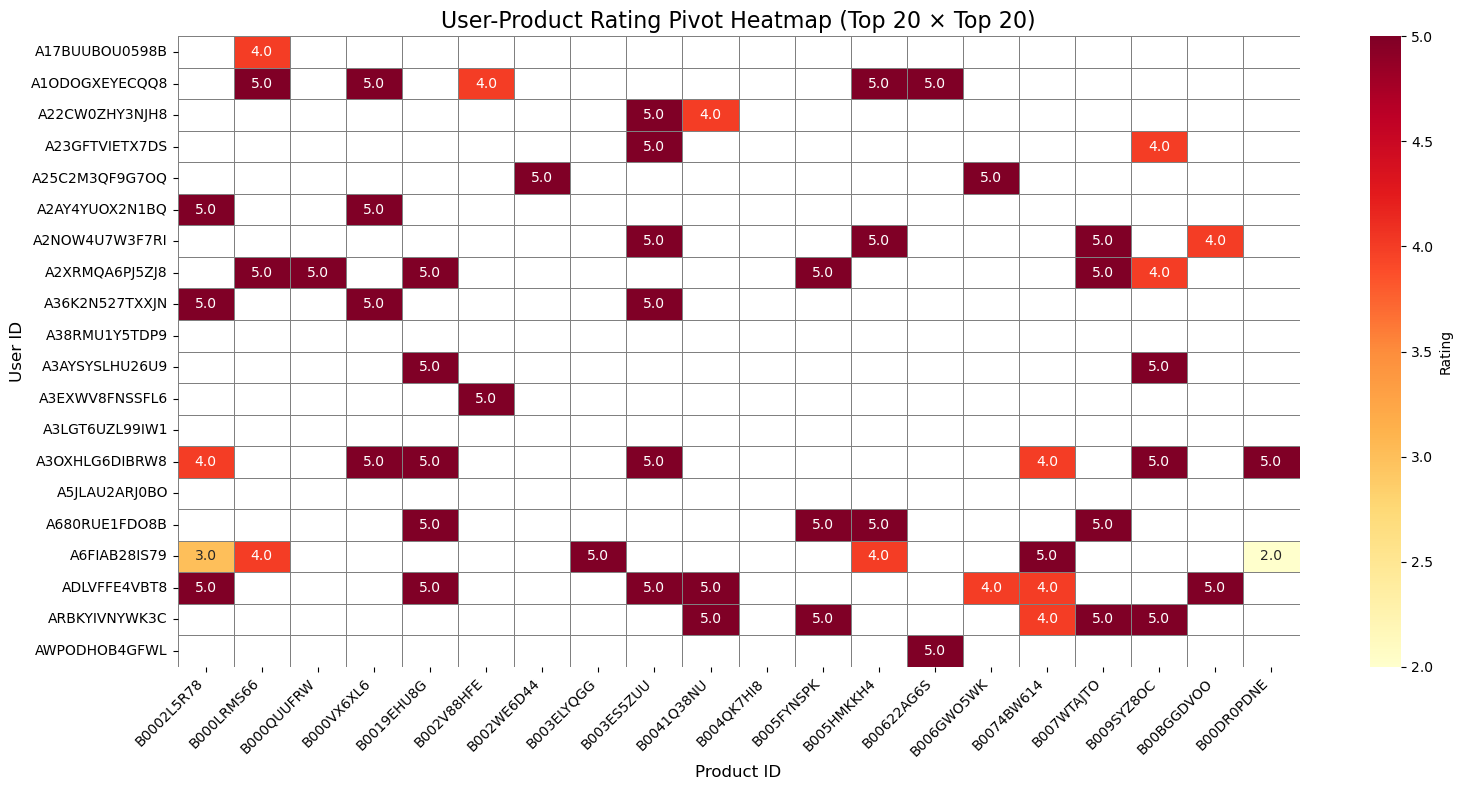

In [45]:
# HEATMAP — Top 20 Users × Top 20 Products from Pivot Table
top_users_list    = df_filtered['userId'].value_counts().head(20).index
top_products_list = df_filtered['productId'].value_counts().head(20).index

# Extract the 20×20 sub-pivot
pivot_sample = pivot_table.loc[
    pivot_table.index.isin(top_users_list),
    pivot_table.columns.isin(top_products_list)
]

plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_sample,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    linecolor='gray',
    cbar_kws={'label': 'Rating'}
)
plt.title("User-Product Rating Pivot Heatmap (Top 20 × Top 20)", fontsize=16)
plt.xlabel("Product ID", fontsize=12)
plt.ylabel("User ID", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
# FILL NaN VALUES — Required before feeding into ML models

# Option A: Fill with 0 → used in memory-based Collaborative Filtering (KNN)
pivot_filled_zero = pivot_table.fillna(0)

# Option B: Fill with product mean rating → used in model-based CF (SVD, ALS)
pivot_filled_mean = pivot_table.apply(lambda col: col.fillna(col.mean()), axis=0)

print("Zero-filled pivot shape:", pivot_filled_zero.shape)
print("Mean-filled pivot shape:", pivot_filled_mean.shape)

Zero-filled pivot shape: (495, 476)
Mean-filled pivot shape: (495, 476)


## 15. Sparse Matrix (Memory Efficient Representation)

In [47]:
# CREATE SPARSE MATRIX — Efficient for large datasets
# Instead of storing NaN, sparse matrix only stores actual ratings
# This saves huge amounts of memory

# Convert userId and productId to integer category codes
user_codes    = df['userId'].astype("category").cat.codes
product_codes = df['productId'].astype("category").cat.codes

# Build CSR (Compressed Sparse Row) matrix
sparse_matrix = csr_matrix(
    (df['Rating'], (user_codes, product_codes))
)

print("Sparse Matrix Shape:", sparse_matrix.shape)
print(sparse_matrix)

Sparse Matrix Shape: (4201696, 476002)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7824482 stored elements and shape (4201696, 476002)>
  Coords	Values
  (0, 195534)	5.0
  (1, 203898)	5.0
  (1, 206615)	5.0
  (2, 372947)	5.0
  (3, 226214)	5.0
  (4, 154932)	5.0
  (5, 438091)	4.0
  (6, 442987)	5.0
  (7, 121039)	1.0
  (8, 212396)	1.0
  (9, 260145)	5.0
  (9, 287545)	5.0
  (9, 314023)	3.0
  (9, 350055)	5.0
  (10, 222074)	5.0
  (10, 269551)	5.0
  (11, 327499)	4.0
  (12, 178698)	5.0
  (12, 298833)	5.0
  (13, 190087)	4.0
  (14, 279378)	4.0
  (15, 183276)	5.0
  (16, 467687)	3.0
  (17, 194182)	5.0
  (18, 239371)	1.0
  :	:
  (4201676, 227242)	1.0
  (4201677, 9814)	1.0
  (4201678, 53513)	5.0
  (4201679, 122995)	5.0
  (4201679, 138877)	5.0
  (4201680, 453642)	5.0
  (4201681, 233991)	5.0
  (4201682, 263966)	2.0
  (4201683, 316575)	5.0
  (4201684, 96831)	4.0
  (4201685, 17506)	4.0
  (4201686, 318319)	4.0
  (4201687, 2872)	2.0
  (4201687, 4387)	5.0
  (4201688, 54778)	5.0
  (4201689, 2

In [48]:
# CALCULATE SPARSITY of the full dataset
sparsity_full = 1.0 - (
    df.shape[0] /
    float(sparse_matrix.shape[0] * sparse_matrix.shape[1])
)
print(f"Dataset Sparsity: {sparsity_full * 100:.4f}%")
# High sparsity means most user-product combinations have no rating

Dataset Sparsity: 99.9996%


## 16. User-Product Interaction Heatmap (From Sparse Matrix)

In [49]:
# Extract sample from sparse matrix for heatmap visualization
# (Visualizing full matrix is not feasible for large datasets)

rows, cols = sparse_matrix.nonzero()  # Get positions of actual ratings

# Get unique active rows and columns from first 30 entries
active_rows = np.unique(rows[:30])
active_cols = np.unique(cols[:30])

# Extract dense sub-matrix using correct sparse matrix slicing
heatmap_sample = sparse_matrix[active_rows][:, active_cols].toarray()

# Convert to DataFrame for heatmap
heatmap_df = pd.DataFrame(heatmap_sample)
heatmap_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


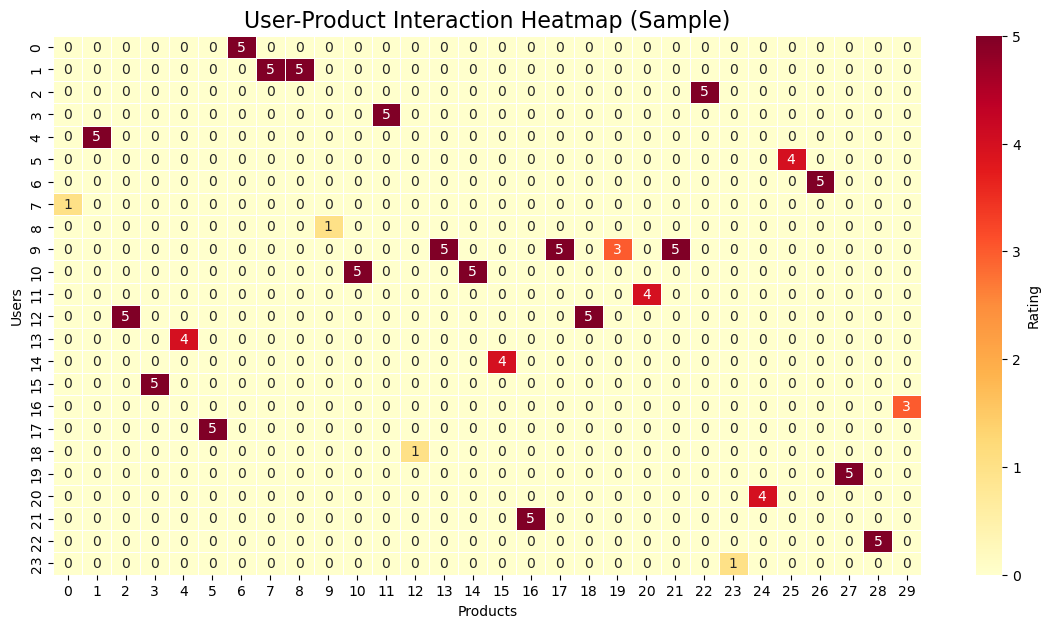

In [50]:
# HEATMAP — User-Product Interaction from Sparse Matrix
plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_df,
    cmap='YlOrRd',
    annot=True,
    linewidths=0.5,
    cbar_kws={'label': 'Rating'}
)
plt.title("User-Product Interaction Heatmap (Sample)", fontsize=16)
plt.xlabel("Products")
plt.ylabel("Users")
plt.show()

## 17. Product Correlation Matrix

In [51]:
# Build a small dense sample from sparse matrix for correlation analysis
rows, cols = sparse_matrix.nonzero()
active_rows = np.unique(rows[:100])
active_cols = np.unique(cols[:100])

# Correct sparse matrix slicing
sample_matrix = sparse_matrix[active_rows][:, active_cols].toarray()
sample_df = pd.DataFrame(sample_matrix)
sample_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
# PRODUCT CORRELATION MATRIX
# Shows how similar products are in terms of user rating patterns
product_correlation = sample_df.corr()
product_correlation.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97
0,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152
1,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152
2,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152
3,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.0151

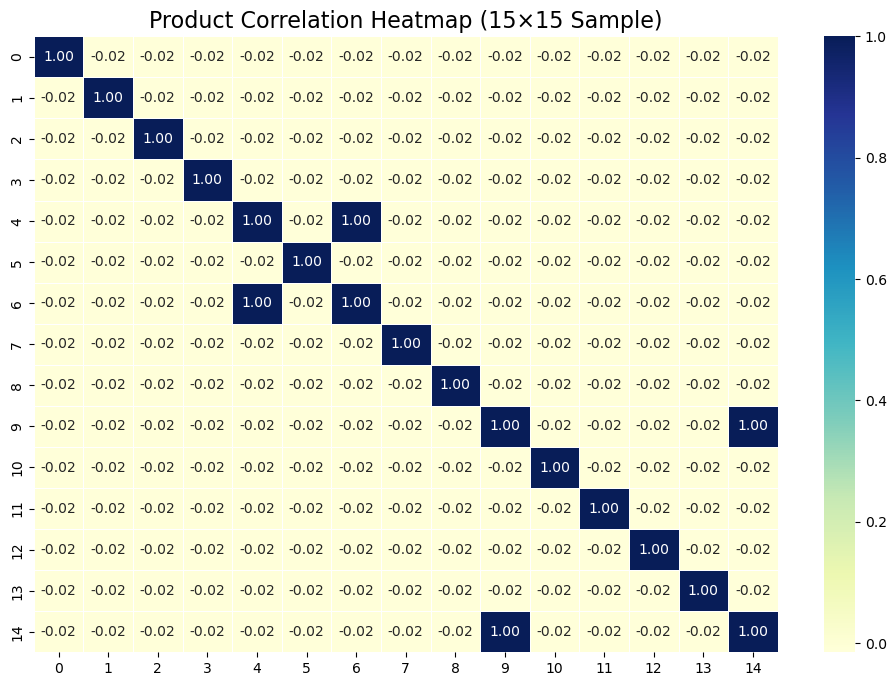

In [53]:
# CORRELATION HEATMAP — Smaller 15×15 for readability
small_corr = product_correlation.iloc[:15, :15]

plt.figure(figsize=(12, 8))
sns.heatmap(
    small_corr,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)
plt.title("Product Correlation Heatmap (15×15 Sample)", fontsize=16)
plt.show()

## 18. Pairplot

In [54]:
# Take a random sample of 500 rows for pairplot
# (Full dataset is too large to plot)
sample_df = df.sample(500, random_state=42)
sample_df.head()

,userId,productId,Rating
1157290,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0
2677500,ALDXDYEGKB27G,B002L6HE9G,4.0
5814180,A15LOGO6NBSI6B,B007MXGG5Q,5.0
6239751,A23LX12CA3G4FG,B008HOEDYU,1.0
5344316,A3TV7QFYXAG130,B0069R7TAM,5.0


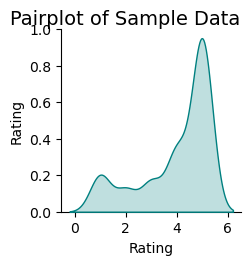

In [55]:
# PAIRPLOT — Visualize relationships between all numeric columns
# Diagonal = KDE distribution, Off-diagonal = scatter plots
sns.pairplot(
    sample_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'color': 'teal'},
    diag_kws={'color': 'teal', 'fill': True}
)
plt.suptitle("Pairplot of Sample Data", y=1.02, fontsize=14)
plt.show()

## 19. Final Insights

In [56]:
# SUMMARY OF KEY FINDINGS FROM EDA
print("""
╔══════════════════════════════════════════════════════════╗
║              EDA FINAL INSIGHTS SUMMARY                  ║
╠══════════════════════════════════════════════════════════╣
║  1. Most users give ratings between 3 and 5              ║
║  2. Very few products receive the majority of ratings    ║
║     → Long-tail distribution observed                    ║
║  3. Dataset is highly sparse (most user-product pairs    ║
║     have no rating)                                      ║
║  4. Some products are outliers in rating count           ║
║     → Handled using IQR capping                          ║
║  5. Many users are generous raters (avg >= 4.0)          ║
║  6. Product popularity follows a long-tail pattern       ║
║  7. User-item pivot table shows high sparsity            ║
║  8. Some products show strong correlation                 ║
║     → Useful for item-based collaborative filtering      ║
║  9. Sparse matrix efficiently stores large rating data   ║
║ 10. Pivot table ready for SVD / KNN / ALS models         ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              EDA FINAL INSIGHTS SUMMARY                  ║
╠══════════════════════════════════════════════════════════╣
║  1. Most users give ratings between 3 and 5              ║
║  2. Very few products receive the majority of ratings    ║
║     → Long-tail distribution observed                    ║
║  3. Dataset is highly sparse (most user-product pairs    ║
║     have no rating)                                      ║
║  4. Some products are outliers in rating count           ║
║     → Handled using IQR capping                          ║
║  5. Many users are generous raters (avg >= 4.0)          ║
║  6. Product popularity follows a long-tail pattern       ║
║  7. User-item pivot table shows high sparsity            ║
║  8. Some products show strong correlation                 ║
║     → Useful for item-based collaborative filtering      ║
║  9. Sparse matrix efficiently stores large rating data   ║
║ 10. Pivot table read